# ⚜️ Taller Aprendizaje no supervisado ⚜️

---

**Integrantes del equipo:** *Jhoan Sebastián Martinez, Juan Sebastián Rivera Valencia, Felipe Grisales lópez y Lucas León*  
**Fecha de entrega:** 15 de abril de 2026  
**Asignatura:** Minería de Datos  

---

Este notebook prepara el dataset de jugadores de fútbol (10.793 registros, 34 columnas) 
para ser usado en algoritmos de aprendizaje no supervisado (K-Means, Clustering Jerárquico).

## 🧪 Configuración del entorno

In [8]:
# 🎲 Importación de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 🧪 Carga e inspección de los datos

In [9]:
# 🎲 Cargar dataset a un DF de Pandas
df_futbol = pd.read_csv("../Enunciado/dataset_futbol_procesado.csv")

print(f"Cantidad de datos: {len(df_futbol)}")
print(f'Filas: {df_futbol.shape[0]} | Columnas: {df_futbol.shape[1]}')

display(df_futbol.head(5))

Cantidad de datos: 10793
Filas: 10793 | Columnas: 34


,Player,Nation,Pos,Pos_principal,Squad,Comp,Age,Born,MP,Starts,...,npxG+xAG,PrgC,PrgP,PrgR,Pos_encoded,Comp_encoded,Age_scaled,MP_scaled,Min_scaled,90s_scaled
0,Brenden Aaronson,USA,MFFW,MFFW,Leeds United,Premier League,22.0,2000.0,20,19,...,NaN,NaN,NaN,NaN,9,3,-0.772391,0.633514,0.912608,0.908568
1,Yunis Abdelhamid,MAR,DF,DF,Reims,Ligue 1,35.0,1987.0,22,22,...,NaN,NaN,NaN,NaN,0,2,2.066543,0.855130,1.424609,1.424562
2,Himad Abdelli,FRA,MFFW,MFFW,Angers,Ligue 1,23.0,1999.0,14,8,...,NaN,NaN,NaN,NaN,9,2,-0.554012,-0.031334,-0.188727,-0.183419
3,Salis Abdul Samed,GHA,MF,MF,Lens,Ligue 1,22.0,2000.0,20,20,...,NaN,NaN,NaN,NaN,7,2,-0.772391,0.633514,1.183275,1.184565
4,Laurent Abergel,FRA,MF,MF,Lorient,Ligue 1,30.0,1993.0,15,15,...,NaN,NaN,NaN,NaN,7,2,0.974645,0.079474,0.337940,0.332575


In [10]:
# 🎲 Resumen de nulos por columna → punto de partida para todas las decisiones
nulos = df_futbol.isnull().sum()
pct   = (nulos / len(df_futbol) * 100).round(1)
resumen = pd.DataFrame({'nulos': nulos, 'porcentaje': pct})
resumen[resumen['nulos'] > 0].sort_values('porcentaje', ascending=False)

,nulos,porcentaje
PrgR,7939,73.6
PrgC,7939,73.6
PrgP,7939,73.6
npxG+xAG,7939,73.6
npxG,7939,73.6
xAG,7939,73.6
xG,7939,73.6
Gls,2689,24.9
Ast,2689,24.9
G+A,2689,24.9


## 🧪 Modificaciones necesarias

**Orden del proceso:**
1. **Eliminación de porteros (GK)**
2. **Decisión sobre duplicados Player + Temporada**
3. **Eliminación de columnas redundantes o inutilizables**
4. **Imputación de valores nulos restantes**
5. **Resumen del proceso y estadísticas finales**
6. **Exportación del dataset limpio**

### 🔱 1. Eliminación de porteros (GK)

**¿Por qué eliminarlos?**

Los porteros (GK) tienen un perfil estadístico estructuralmente diferente al de los jugadores 
de campo: no se les registran goles, asistencias, ni la mayoría de métricas ofensivas. 
Si se incluyen en el clustering, el algoritmo los separa automáticamente en un cluster propio 
simplemente porque tienen muchos ceros → no porque compartan patrones de juego relevantes 
entre sí. Esto "contamina" los demás clusters y distorsiona los centroides sin aportar 
valor analítico real al análisis.

In [11]:
print(f'Distribución de posiciones antes del filtro:')
print(df_futbol['Pos_principal'].value_counts())
print(f'\nTotal porteros (GK): {(df_futbol["Pos_principal"] == "GK").sum()}')

Distribución de posiciones antes del filtro:
Pos_principal
MF      3818
DF      3429
FW      2169
GK       694
FWMF     244
MFFW     208
DFMF     101
MFDF      62
DFFW      38
FWDF      30
Name: count, dtype: int64

Total porteros (GK): 694


In [12]:
# 🎲 Eliminar porteros → se excluye la posición 'GK' de Pos_principal
# Pasamos de 10.793 a → 10.099 registros
df_no_gk = df_futbol[df_futbol['Pos_principal'] != 'GK'].copy()
df_no_gk = df_no_gk.reset_index(drop=True)

print(f'Filas tras eliminar GK: {len(df_no_gk)}')
print(f'Posiciones restantes: {df_no_gk["Pos_principal"].unique()}')

Filas tras eliminar GK: 10099
Posiciones restantes: <StringArray>
['MFFW', 'DF', 'MF', 'FWMF', 'FW', 'DFFW', 'MFDF', 'DFMF', 'FWDF']
Length: 9, dtype: str


### 🔱 2. Decisión sobre duplicados Player + Temporada

**¿Qué son estos duplicados?**

Un mismo jugador aparece varias veces en la misma temporada cuando fue cedido o 
transferido a otro equipo a mitad de año. Por ejemplo, Khusanov aparece con 
Manchester City (503 min) y con Lens (975 min) en 2024-25.

**Se decide conservarlos.**

Pues, cada fila representa el desempeño real del jugador **en un equipo específico** durante 
esa temporada. Agregar o colapsar esas filas perdería información táctica valiosa: 
el mismo jugador puede tener roles distintos en equipos distintos, y eso es exactamente 
lo que el clustering puede capturar. No son errores de datos — son registros legítimos.

In [13]:
# 🎲 Verificación: mostrar un ejemplo de duplicado para confirmar que son transferencias
ejemplo = df_no_gk[df_no_gk.duplicated(subset=['Player','Temporada'], keep=False)]
ejemplo = ejemplo.sort_values(['Player','Temporada'])

# 🎲 Mostramos los primeros dos jugadores para ilustrar el caso
jugadores_dup = ejemplo['Player'].unique()[:2]
cols_muestra  = ['Player', 'Temporada', 'Squad', 'Pos_principal', 'Min', 'Gls', 'Ast']

print(f'Total duplicados Player+Temporada: {df_no_gk.duplicated(subset=["Player","Temporada"]).sum()}')
print('\nEjemplo de jugadores con doble registro (transferencias):')
display(ejemplo[ejemplo['Player'].isin(jugadores_dup)][cols_muestra])

Total duplicados Player+Temporada: 568

Ejemplo de jugadores con doble registro (transferencias):


,Player,Temporada,Squad,Pos_principal,Min,Gls,Ast
4725,Abakar Sylla,2023-24,Strasbourg,DF,2,0.0,0.0
4726,Abakar Sylla,2023-24,Nantes,DF,20,0.0,0.0
9833,Abakar Sylla,2025-26,Strasbourg,DF,2,0.0,0.0
9834,Abakar Sylla,2025-26,Nantes,DF,20,0.0,0.0
6263,Abdukodir Khusanov,2024-25,Manchester City,DF,503,0.0,0.0
6264,Abdukodir Khusanov,2024-25,Lens,DF,975,0.0,0.0


### 🔱 3. Eliminación de columnas

Se eliminan columnas por tres razones distintas, explicadas a continuación.

#### 👾 Columnas **_scaled** → redundantes con sus originales

Las columnas **Age_scaled**, **MP_scaled**, **Min_scaled** y **90s_scaled** tienen una 
correlación de **1.0** con **Age**, **MP**, **Min** y **90s** respectivamente. Son exactamente 
la misma información transformada. 

**Motivo de eliminación:** Incluirlas duplica el peso de esas cuatro variables en el 
cálculo de distancias de K-Means, sesgando los clusters hacia esas métricas. Orange 
aplica normalización internamente con el widget **Normalize**, así que estas columnas 
no aportan nada y solo introducen redundancia.

In [14]:
cols_scaled = ['Age_scaled', 'MP_scaled', 'Min_scaled', '90s_scaled']

# 🎲 Confirmamos correlación perfecta antes de eliminar
pares = [('Age','Age_scaled'), ('MP','MP_scaled'), ('Min','Min_scaled'), ('90s','90s_scaled')]
print('Correlaciones (deben ser 1.0):')
for orig, sc in pares:
    print(f'  {orig:5s} ↔ {sc}: {df_no_gk[orig].corr(df_no_gk[sc]):.6f}')

df_no_gk.drop(columns=cols_scaled, inplace=True)
print(f'\nColumnas eliminadas: {cols_scaled}')

Correlaciones (deben ser 1.0):
  Age   ↔ Age_scaled: 1.000000
  MP    ↔ MP_scaled: 1.000000
  Min   ↔ Min_scaled: 1.000000
  90s   ↔ 90s_scaled: 1.000000

Columnas eliminadas: ['Age_scaled', 'MP_scaled', 'Min_scaled', '90s_scaled']


#### 👾 Columnas con 73% de nulos → no recuperables

Las columnas **xG**, **xAG**, **npxG**, **npxG+xAG**, **PrgC**, **PrgP** y **PrgR** tienen el 
73.6% de sus valores en nulo. Inicialmente se pensó que era por los porteros, 
pero al verificarlo, el **73.8% de los jugadores de campo también tienen nulos** 
en estas columnas. Es un problema de disponibilidad del dato en FBRef: estas 
métricas avanzadas no están disponibles para todas las ligas ni temporadas.

**Motivo de eliminación:** Con más del 70% de nulos, imputar estos valores (por 
ejemplo con la mediana) introduciría ruido artificial masivo que deformaría los 
clusters. La información que aportan no justifica el riesgo de contaminación. 
Se eliminan completamente del análisis.

In [15]:
cols_73_pct = ['xG', 'xAG', 'npxG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR']

# 🎲 Verificamos la distribución de nulos antes de eliminar
print('Nulos en columnas con alta tasa de ausencia:')
for col in cols_73_pct:
    pct = df_no_gk[col].isnull().sum() / len(df_no_gk) * 100
    print(f'  {col:15s}: {pct:.1f}% nulos')

df_no_gk.drop(columns=cols_73_pct, inplace=True)
print(f'\nColumnas eliminadas: {cols_73_pct}')

Nulos en columnas con alta tasa de ausencia:
  xG             : 73.8% nulos
  xAG            : 73.8% nulos
  npxG           : 73.8% nulos
  npxG+xAG       : 73.8% nulos
  PrgC           : 73.8% nulos
  PrgP           : 73.8% nulos
  PrgR           : 73.8% nulos

Columnas eliminadas: ['xG', 'xAG', 'npxG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR']


#### 👾 Columnas redundantes por alta correlación

Se identificaron pares de columnas que miden prácticamente lo mismo:

- **`90s` vs `Min`**: `90s` = `Min / 90` — correlación 1.0. Se elimina `90s`.
- **`Starts` vs `Min`**: correlación 0.993. `Min` es más informativa (captura
  suplentes que entran poco). Se elimina `Starts`.
- **`G-PK` vs `Gls`**: correlación 0.977. `Gls` incluye penales (más completa).
  Se elimina `G-PK`.
- **`G+A`**: es la suma de `Gls` + `Ast`, ya representadas individualmente.
  Se elimina para evitar triple conteo.
- **`Born`**: año de nacimiento, contiene exactamente la misma información 
  que `Age`. Se elimina `Born`.

**Nota sobre `PK` y `PKatt`**: aunque su correlación es alta (0.961), representan 
conceptos distintos (penales convertidos vs intentados) y ambos tienen baja 
varianza general. Se conservan porque penales marcados vs intentados puede ser 
un rasgo diferenciador para algunos jugadores.

In [16]:
cols_redundantes = [
    '90s',    # = Min / 90 — correlación 1.0 con Min
    'Starts', # correlación 0.993 con Min — Min es más granular
    'G-PK',   # correlación 0.977 con Gls — Gls es más completa
    'G+A',    # = Gls + Ast — ya representadas por separado
    'Born',   # = misma info que Age — redundante
]

df_no_gk.drop(columns=cols_redundantes, inplace=True)
print(f'Columnas eliminadas por redundancia: {cols_redundantes}')
print(f'\nColumnas restantes ({df_no_gk.shape[1]}):')
print(df_no_gk.columns.tolist())

Columnas eliminadas por redundancia: ['90s', 'Starts', 'G-PK', 'G+A', 'Born']

Columnas restantes (18):
['Player', 'Nation', 'Pos', 'Pos_principal', 'Squad', 'Comp', 'Age', 'MP', 'Min', 'CrdY', 'CrdR', 'Temporada', 'PKatt', 'Gls', 'Ast', 'PK', 'Pos_encoded', 'Comp_encoded']


#### 👾 Columnas de identificación → no usables en clustering

Las columnas `Player`, `Nation`, `Pos`, `Squad`, `Comp` y `Temporada` son 
identificadores o categóricas de texto libre. No aportan información numérica 
al algoritmo y no pueden usarse directamente en K-Means.

**Decisión:** Se separan en un DataFrame auxiliar (`df_meta`) que se usará 
al final para interpretar y etiquetar los clusters. No se eliminan del entorno, 
solo se excluyen del DataFrame de entrenamiento (`df_cluster`).

Se conservan `Pos_encoded` y `Comp_encoded` (ya numéricas) para el clustering.

| **Mapeo de posiciones:** | **Mapeo de ligas:** |
| ------------------------ | ------------------- |
| 0 → DF                   | 0 → Bundesliga      |
| 1 → DFFW                 | 1 → La Liga         |
| 2 → DFMF                 | 2 → Ligue 1         |
| 3 → FW                   | 3 → Premier League  |
| 4 → FWDF                 | 4 → Serie A         |
| 5 → FWMF                 |                     |
| 6 → GK                   |                     |
| 7 → MF                   |                     |
| 8 → MFDF                 |                     |
| 9 → MFFW                 |                     |

In [17]:
cols_meta = ['Player', 'Nation', 'Pos', 'Pos_principal', 'Squad', 'Comp', 'Temporada']

# 🎲🎲 Guardamos las columnas de identificación para uso posterior (interpretar clusters)
df_meta = df_no_gk[cols_meta].copy()

# 🎲🎲 Dataset de clustering: solo columnas numéricas
df_cluster = df_no_gk.drop(columns=cols_meta).copy()

print(f'df_meta    → {df_meta.shape[1]} columnas de identificación, {len(df_meta)} filas')
print(f'df_cluster → {df_cluster.shape[1]} columnas numéricas para clustering, {len(df_cluster)} filas')
print(f'\nColumnas del dataset de clustering:')
print(df_cluster.columns.tolist())

df_meta    → 7 columnas de identificación, 10099 filas
df_cluster → 11 columnas numéricas para clustering, 10099 filas

Columnas del dataset de clustering:
['Age', 'MP', 'Min', 'CrdY', 'CrdR', 'PKatt', 'Gls', 'Ast', 'PK', 'Pos_encoded', 'Comp_encoded']


### 🔱 4. Imputación de valores nulos restantes

Tras las eliminaciones anteriores, quedan nulos en:
- `Age`: 8 registros (< 0.1%) — se imputa con la **mediana general**
- `Gls`, `Ast`, `PK`: ~25% de nulos

**Estrategia para `Gls`, `Ast`, `PK`:**

Estos nulos no indican que el dato no exista — indican que FBRef no lo reportó 
para esa combinación de liga/temporada. En la práctica, si no se reporta, 
el valor real es muy probablemente 0 o cercano a 0 (jugadores con poca participación). 
Se imputa con la **mediana por posición principal**, que respeta las diferencias 
naturales entre roles: un delantero con Gls nulo es distinto a un defensa con Gls nulo.

In [18]:
# 🎲 4.1 Age — 8 nulos (< 0.1%): imputar con mediana general
mediana_age = df_cluster['Age'].median()
df_cluster['Age'] = df_cluster['Age'].fillna(mediana_age)
print(f'Age: imputado con mediana = {mediana_age}')

Age: imputado con mediana = 25.0


In [19]:
# 🎲 4.2 Gls, Ast, PK (~25% nulos): imputar con mediana por Pos_principal
# 🎲 Usamos df_meta['Pos_principal'] como agrupador porque ya fue separado de df_cluster

cols_imputar = ['Gls', 'Ast', 'PK']

# 🎲 Adjuntamos temporalmente la posición para calcular la mediana por grupo
df_temp = df_cluster.copy()
df_temp['Pos_principal'] = df_meta['Pos_principal'].values

for col in cols_imputar:
    nulos_antes = df_temp[col].isnull().sum()
    # Mediana por posición
    mediana_pos = df_temp.groupby('Pos_principal')[col].transform('median')
    df_cluster[col] = df_temp[col].fillna(mediana_pos)
    # Si aún quedan nulos (posición sin datos), rellenar con mediana global
    if df_cluster[col].isnull().any():
        df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())
    nulos_despues = df_cluster[col].isnull().sum()
    print(f'{col:5s}: {nulos_antes} nulos → {nulos_despues} nulos (imputado por mediana de posición)')

Gls  : 2525 nulos → 0 nulos (imputado por mediana de posición)
Ast  : 2525 nulos → 0 nulos (imputado por mediana de posición)
PK   : 2525 nulos → 0 nulos (imputado por mediana de posición)


In [20]:
# 🎲 Verificación final: no debe quedar ningún nulo en df_cluster
nulos_finales = df_cluster.isnull().sum().sum()
print(f'Nulos totales en df_cluster: {nulos_finales}')

if nulos_finales == 0:
    print('✓ Dataset limpio — listo para clustering')
else:
    print('✗ Aún hay nulos — revisar columnas:')
    print(df_cluster.isnull().sum()[df_cluster.isnull().sum() > 0])

Nulos totales en df_cluster: 0
✓ Dataset limpio — listo para clustering


### 🔱 5. Resumen del proceso y estadísticas finales

In [21]:
print('='*55)
print('RESUMEN DE PREPROCESAMIENTO')
print('='*55)
print(f'Registros originales          : 10.793')
print(f'Registros tras eliminar GK    : {len(df_cluster):>6,}')
print(f'Columnas originales           : 34')
print(f'Columnas en df_cluster        : {df_cluster.shape[1]:>6}')
print()
print('Columnas eliminadas:')
print('  _scaled      (4) → redundantes con originales')
print('  73% nulos    (7) → xG, xAG, npxG, npxG+xAG, PrgC, PrgP, PrgR')
print('  Redundantes  (5) → 90s, Starts, G-PK, G+A, Born')
print('  Identificad. (7) → separadas a df_meta')
print()
print('Columnas finales del clustering:')
for col in df_cluster.columns:
    print(f'  • {col}')

RESUMEN DE PREPROCESAMIENTO
Registros originales          : 10.793
Registros tras eliminar GK    : 10,099
Columnas originales           : 34
Columnas en df_cluster        :     11

Columnas eliminadas:
  _scaled      (4) → redundantes con originales
  73% nulos    (7) → xG, xAG, npxG, npxG+xAG, PrgC, PrgP, PrgR
  Redundantes  (5) → 90s, Starts, G-PK, G+A, Born
  Identificad. (7) → separadas a df_meta

Columnas finales del clustering:
  • Age
  • MP
  • Min
  • CrdY
  • CrdR
  • PKatt
  • Gls
  • Ast
  • PK
  • Pos_encoded
  • Comp_encoded


In [22]:
# 🎲 Estadísticas descriptivas del dataset final
df_cluster.describe().round(2)

,Age,MP,Min,CrdY,CrdR,PKatt,Gls,Ast,PK,Pos_encoded,Comp_encoded
count,10099.00,10099.00,10099.00,10099.00,10099.00,10099.00,10099.00,10099.00,10099.00,10099.00,10099.00
mean,25.35,14.27,885.38,1.58,0.08,0.13,1.16,0.80,0.10,3.68,2.06
std,4.44,8.95,730.57,2.07,0.31,0.62,2.27,1.44,0.53,3.11,1.40
min,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,22.00,7.00,227.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
50%,25.00,15.00,773.00,1.00,0.00,0.00,0.00,0.00,0.00,3.00,2.00
75%,28.00,20.00,1394.50,2.00,0.00,0.00,1.00,1.00,0.00,7.00,3.00
max,42.00,38.00,3420.00,15.00,10.00,9.00,31.00,18.00,9.00,9.00,4.00


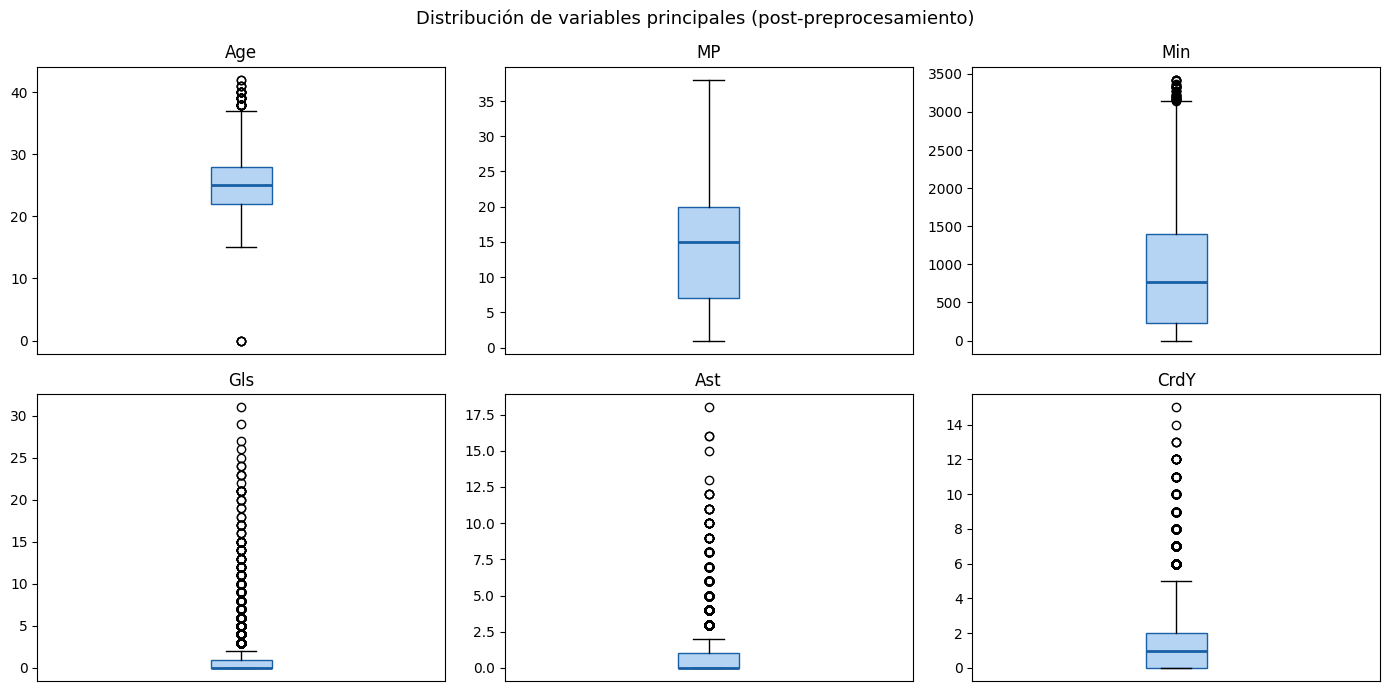

In [23]:
# 🎲 Distribución de variables numéricas clave (boxplots)
cols_plot = ['Age', 'MP', 'Min', 'Gls', 'Ast', 'CrdY']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    axes[i].boxplot(df_cluster[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                    medianprops=dict(color='#185FA5', linewidth=2))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xticks([])

fig.suptitle('Distribución de variables principales (post-preprocesamiento)', fontsize=13)
plt.tight_layout()
plt.savefig('distribucion_variables.png', dpi=120, bbox_inches='tight')
plt.show()

### 🔱 6. Exportación

Se exportan dos archivos:
- **`dataset_clustering.csv`** → columnas numéricas listas para Orange (sin normalizar; 
  Orange aplica su propio `Normalize` antes de K-Means)
- **`dataset_completo_limpio.csv`** → dataset completo con metadatos para interpretar 
  los clusters una vez generados

In [24]:
# 🎲 Archivo para Orange — solo columnas numéricas
df_cluster.to_csv('dataset_clustering.csv', index=False)
print(f'Exportado: dataset_clustering.csv ({df_cluster.shape[0]} filas, {df_cluster.shape[1]} columnas)')

# 🎲 Archivo completo con metadatos — útil para interpretar los clusters
df_completo = pd.concat([df_meta.reset_index(drop=True), df_cluster.reset_index(drop=True)], axis=1)
df_completo.to_csv('dataset_completo_limpio.csv', index=False)
print(f'Exportado: dataset_completo_limpio.csv ({df_completo.shape[0]} filas, {df_completo.shape[1]} columnas)')

Exportado: dataset_clustering.csv (10099 filas, 11 columnas)
Exportado: dataset_completo_limpio.csv (10099 filas, 18 columnas)
